In [8]:

# Required libraries
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image


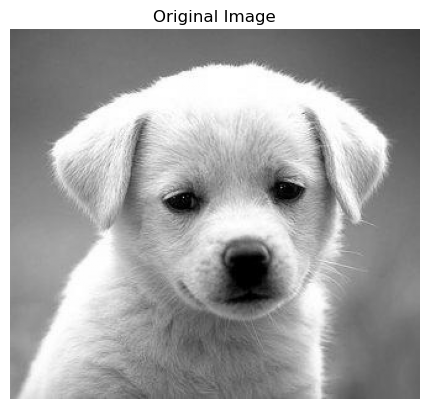

In [9]:

# We load the image and convert it to grayscale because
# Grayscale makes processing easier as it is 1 channel instead of 3.
image = Image.open("dog.jpg").convert("L")

# We convert image to numpy array and float type so we can perform mathematical operations accurately without data overflow or rounding errors.
image = np.array(image, dtype=np.float32)

# Show the image
plt.imshow(image, cmap='gray')
plt.title("Original Image")
plt.axis("off")
plt.show()


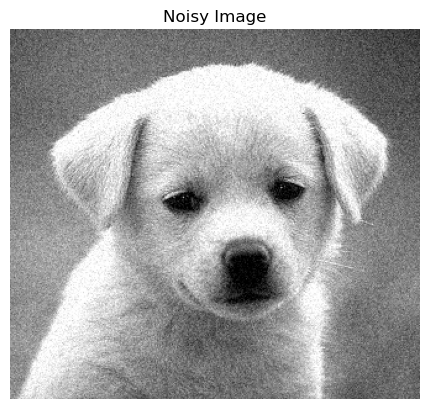

In [10]:

# Add Gaussian noise with:
# Mean = 0
# Standard deviation = 15

mean = 0
std = 15

# Generate random noise of same shape as image
noise = np.random.normal(mean, std, image.shape)

# Add noise to image
noisy_image = image + noise

# Clip values so they stay between 0 and 255
noisy_image = np.clip(noisy_image, 0, 255)

# Show noisy image
plt.imshow(noisy_image, cmap='gray')
plt.title("Noisy Image")
plt.axis("off")
plt.show()


In [11]:

# Creating our own convolution function
# We:
# 1. Flip the kernel
# 2. Apply zero padding
# 3. Slide the kernel over the image
# 4. Compute weighted sum at each pixel

def convolve2d(image, kernel):
    kernel_height, kernel_width = kernel.shape
    image_height, image_width = image.shape

    # Flip kernel horizontally and vertically
    kernel = np.flipud(np.fliplr(kernel))

    # Calculate padding size
    pad_h = kernel_height // 2
    pad_w = kernel_width // 2

    # Apply zero padding
    padded_image = np.pad(image,
                          ((pad_h, pad_h), (pad_w, pad_w)),
                          mode='constant')

    # Create output image
    output = np.zeros_like(image)

    # Perform convolution
    for i in range(image_height):
        for j in range(image_width):
            region = padded_image[i:i+kernel_height, j:j+kernel_width]
            output[i, j] = np.sum(region * kernel)

    return output


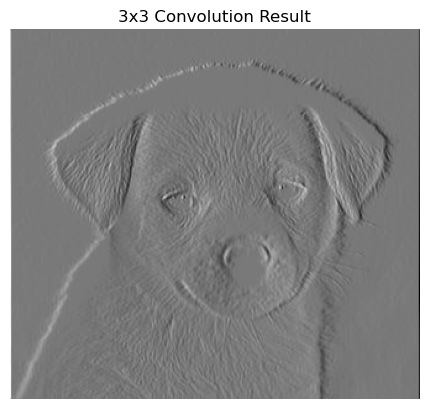

In [12]:

# Given 3x3 kernel
kernel_3x3 = np.array([[1, 0, -1],
                       [2, 0, -2],
                       [1, 0, -1]])

# Apply convolution
conv_result = convolve2d(image, kernel_3x3)

plt.imshow(conv_result, cmap='gray')
plt.title("3x3 Convolution Result")
plt.axis("off")
plt.show()


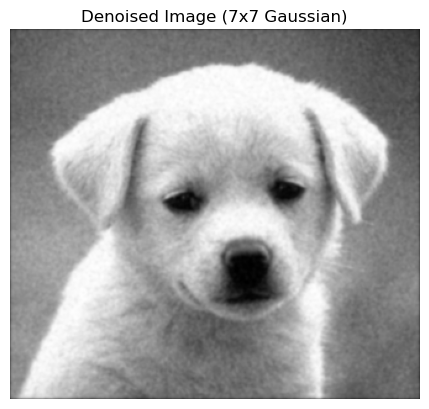

In [13]:

# Creating a Gaussian kernel (7x7) with sigma = 1.0

def gaussian_kernel(size, sigma):
    ax = np.linspace(-(size//2), size//2, size)
    xx, yy = np.meshgrid(ax, ax)
    kernel = np.exp(-(xx**2 + yy**2) / (2 * sigma**2))
    return kernel / np.sum(kernel)

gaussian_7x7 = gaussian_kernel(7, 1.0)

# We apply to noisy image to remove noise
denoised_image = convolve2d(noisy_image, gaussian_7x7)

plt.imshow(denoised_image, cmap='gray')
plt.title("Denoised Image (7x7 Gaussian)")
plt.axis("off")
plt.show()


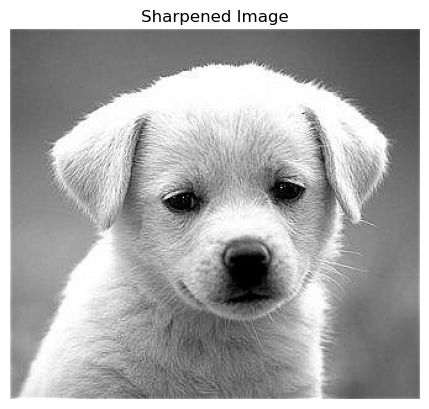

In [14]:

# Given Sharpening Kernel

sharpening_kernel = np.array([
    [1, 4, 6, 4, 1],
    [4, 16, 24, 16, 4],
    [6, 24, -476, 24, 6],
    [4, 16, 24, 16, 4],
    [1, 4, 6, 4, 1]
]) * (-1.0 / 256.0)

# Apply sharpening
sharpened_image = convolve2d(image, sharpening_kernel)

# Clip values
sharpened_image = np.clip(sharpened_image, 0, 255)

plt.imshow(sharpened_image, cmap='gray')
plt.title("Sharpened Image")
plt.axis("off")
plt.show()
